In [3]:
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

import seaborn as sns
palette = sns.color_palette('flare', 6)
palette

[(0.9155979, 0.55210684, 0.42070204),
 (0.888292, 0.40830288, 0.36223756),
 (0.81942908, 0.28911553, 0.38102921),
 (0.69226314, 0.23413578, 0.42480327),
 (0.56041794, 0.19845221, 0.44207535),
 (0.42355299, 0.16934709, 0.42581586)]

## Tull Spectra

In January 2025, I observed WB74a and WB74b back to back.  Each object got 2 individual sub-exposures. Let's plot the individual exposures. Note: these are already continuum normalized and rv-corrected.

In [4]:
#individual exposures
WB74_a_tull_spectra = ['/mnt/wwn-0x50014ee2c0fe636b-part1/GZRedux/20250107/reduce/BACCHUS/Science0305.txt',
                      '/mnt/wwn-0x50014ee2c0fe636b-part1/GZRedux/20250107/reduce/BACCHUS/Science0306.txt']

WB74_b_tull_spectra = ['/mnt/wwn-0x50014ee2c0fe636b-part1/GZRedux/20250107/reduce/BACCHUS/Science0307.txt',
                      '/mnt/wwn-0x50014ee2c0fe636b-part1/GZRedux/20250107/reduce/BACCHUS/Science0308.txt']

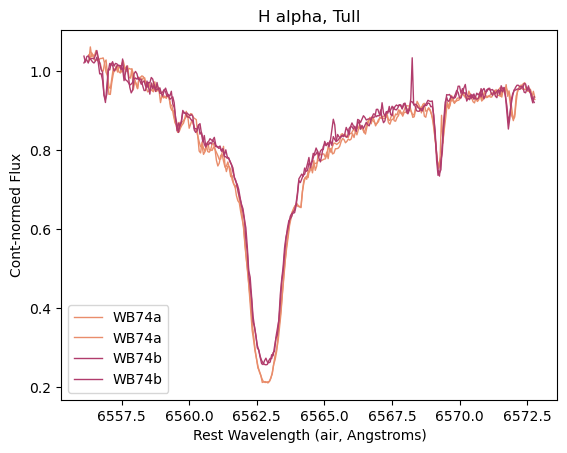

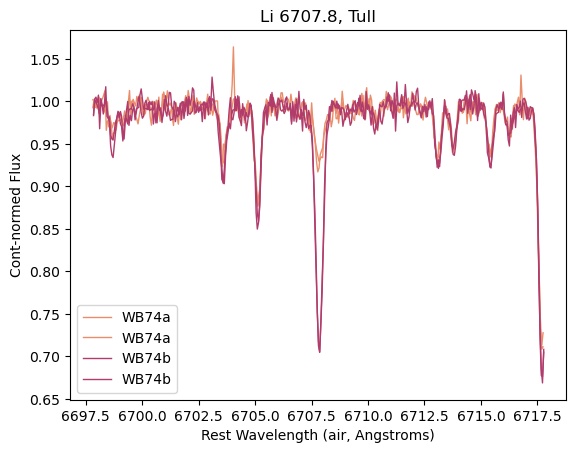

In [5]:
for file in WB74_a_tull_spectra:
    spec = Table.read(file, format='ascii')
    Li = np.where(np.abs(spec['waveobs'] - 6562.8) < 10)
    plt.plot(spec['waveobs'][Li], spec['flux'][Li], c=palette[0], label='WB74a', lw=1)
    plt.title('H alpha, Tull')
for file in WB74_b_tull_spectra:
    spec = Table.read(file, format='ascii')
    Li = np.where(np.abs(spec['waveobs'] - 6562.8) < 10)
    plt.plot(spec['waveobs'][Li], spec['flux'][Li], c=palette[3], label='WB74b', lw=1)
plt.legend()
plt.xlabel('Rest Wavelength (air, Angstroms)')
plt.ylabel('Cont-normed Flux')
plt.show()

for file in WB74_a_tull_spectra:
    spec = Table.read(file, format='ascii')
    Li = np.where(np.abs(spec['waveobs'] - 6707.8) < 10)
    plt.plot(spec['waveobs'][Li], spec['flux'][Li], c=palette[0], label='WB74a', lw=1)
    plt.title('Li 6707.8, Tull')
for file in WB74_b_tull_spectra:
    spec = Table.read(file, format='ascii')
    Li = np.where(np.abs(spec['waveobs'] - 6707.8) < 10)
    plt.plot(spec['waveobs'][Li], spec['flux'][Li], c=palette[3], label='WB74b', lw=1)
plt.legend()
plt.xlabel('Rest Wavelength (air, Angstroms)')
plt.ylabel('Cont-normed Flux')
plt.show()

## MAROON-X Spectra 

MAROON-X observed WB74a on Oct 1,2,and 3.  They observed WB74b on Oct 2 and 3.

I ran their reduction pipeline (https://maroonxdr.readthedocs.io/latest/tutorials/MAROONXDR_Tutorial/intro.html) two times. It is not hard to run, but collecting the right calibration frames was challenging.  Flats have to be taken within 1 week, darks within a few days, and wavelength calibration frames (called etalons) are taken nightly.

The reduction pipeline returns extracted 1D spectra that are wavelength calibrated but not blaze corrected or rv-corrected.  Let's plot the reduced MAROON-X Spectra.  

In [6]:
#dictionary for translating file names into object
file_to_object = {
    "N20261001M5559": "HD 79872A",
    "N20261002M5616": "HD 79872B",
    "N20261002M5643": "HD 79872A",
    "N20261003M5421": "HD 79872B",
    "N20261003M5458": "HD 79872A",
}

#all Maroon-X files
fnames = ["/home/catherine-manea/Software/MAROONXDR/Data_oct3/N20261003M5458_reduced.fits", #HD 79872A
          "/home/catherine-manea/Software/MAROONXDR/Data_oct3/N20261003M5421_reduced.fits", #HD 79872B
          "/home/catherine-manea/Software/MAROONXDR/Data_oct2/N20261002M5643_reduced.fits", #HD 79872A
          "/home/catherine-manea/Software/MAROONXDR/Data_oct2/N20261002M5616_reduced.fits", #HD 79872B
          "/home/catherine-manea/Software/MAROONXDR/Data_oct1/N20261001M5559_reduced.fits"] #HD 79872A

#split files by object
WB74_a_MAROONX_spectra = [
                        "/home/catherine-manea/Software/MAROONXDR/Data_oct3/N20261003M5458_reduced.fits", #HD 79872A
                          "/home/catherine-manea/Software/MAROONXDR/Data_oct2/N20261002M5643_reduced.fits", #HD 79872A
                          "/home/catherine-manea/Software/MAROONXDR/Data_oct1/N20261001M5559_reduced.fits"] #HD 79872A

WB74_b_MAROONX_spectra = ["/home/catherine-manea/Software/MAROONXDR/Data_oct3/N20261003M5421_reduced.fits", #HD 79872B
                          "/home/catherine-manea/Software/MAROONXDR/Data_oct2/N20261002M5616_reduced.fits"] #HD 79872B



To plot the reduced MAROON-X, we need to pick the arm (red or blue), the order (what wavelength chunk you want to see), and also the fiber.

There are 3 object fibers, Fiber 2, 3, and 4.  Additionally, Fiber 1 is a sky fiber, Fiber 5 is the etalon, Fiber 6 is supposedly the final object spectrum combined across all three object fibers.  

To be safe I will stick to an individual object fiber, Fiber 3.

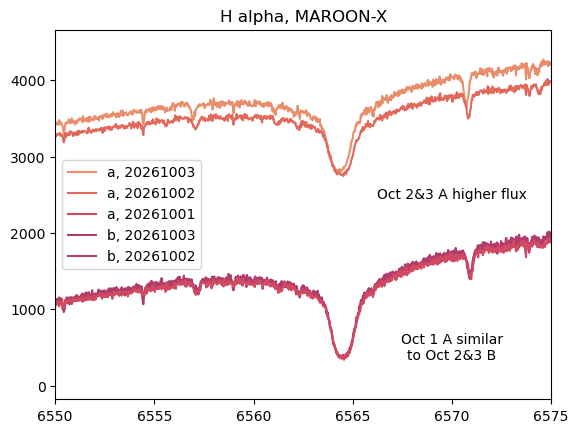

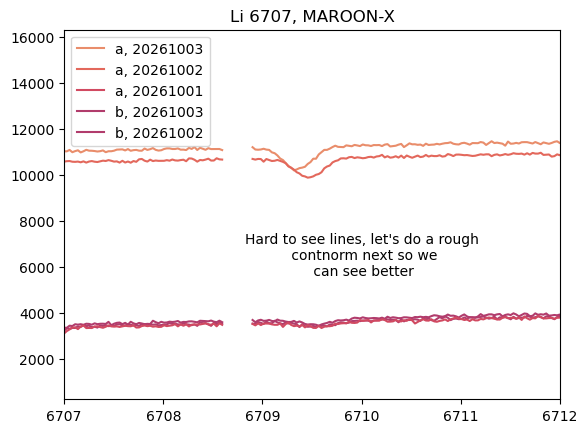

In [7]:
#----Halpha
arm = "BLUE"    # BLUE OR RED 
order =  2  #RED order 24 has Li, BLUE order 2 has Halpha

if arm == "BLUE":
    extver = 1
elif arm == "RED":
    extver = 2

for j, filename in enumerate(WB74_a_MAROONX_spectra):
    date = filename.split('/')[-1].split('_')[0].split('M')[0].strip('N')
    with fits.open(filename) as hdu:
        fluxes = np.asarray(hdu[("BOX_REDUCED_FIBER_3", extver)].data,dtype=float)[order]
        waves = np.asarray(hdu[("WLS_SIMULTANEOUS_FIBER_3", extver)].data,dtype=float)[order]*10
        plt.plot(waves, fluxes, label=f'a, {date}', c=palette[j])

        

for filename in WB74_b_MAROONX_spectra:
    date = filename.split('/')[-1].split('_')[0].split('M')[0].strip('N')
    with fits.open(filename) as hdu:
        fluxes = np.asarray(hdu[("BOX_REDUCED_FIBER_3", extver)].data,dtype=float)[order]
        waves = np.asarray(hdu[("WLS_SIMULTANEOUS_FIBER_3", extver)].data,dtype=float)[order]*10
        plt.plot(waves, fluxes, c=palette[3], label=f'b, {date}', zorder=0)

plt.xlim(6550, 6575)

plt.text(6570, 500, 'Oct 1 A similar\nto Oct 2&3 B', va='center',ha='center')
plt.text(6570, 2500, 'Oct 2&3 A higher flux', va='center',ha='center')
plt.title('H alpha, MAROON-X')
plt.legend()

plt.show()

#----Lithium
arm = "RED"    # BLUE OR RED 
order =  24  #RED order 24 has Li, BLUE order 2 has Halpha

if arm == "BLUE":
    extver = 1
elif arm == "RED":
    extver = 2

for j, filename in enumerate(WB74_a_MAROONX_spectra):
    date = filename.split('/')[-1].split('_')[0].split('M')[0].strip('N')
    with fits.open(filename) as hdu:
        fluxes = np.asarray(hdu[("BOX_REDUCED_FIBER_3", extver)].data,dtype=float)[order]
        waves = np.asarray(hdu[("WLS_SIMULTANEOUS_FIBER_3", extver)].data,dtype=float)[order]*10
        plt.plot(waves, fluxes, label=f'a, {date}', c=palette[j])

for filename in WB74_b_MAROONX_spectra:
    date = filename.split('/')[-1].split('_')[0].split('M')[0].strip('N')
    with fits.open(filename) as hdu:
        fluxes = np.asarray(hdu[("BOX_REDUCED_FIBER_3", extver)].data,dtype=float)[order]
        waves = np.asarray(hdu[("WLS_SIMULTANEOUS_FIBER_3", extver)].data,dtype=float)[order]*10
        plt.plot(waves, fluxes, c=palette[3], label=f'b, {date}', zorder=0)

plt.xlim(6707, 6712)

plt.text(6710, 6500, "Hard to see lines, let's do a rough\n contnorm next so we\n can see better", va='center',ha='center')
# plt.text(6570, 2500, 'Oct 2&3 A Halpha\n very shallow..', va='center',ha='center')
plt.title('Li 6707, MAROON-X')
plt.legend()

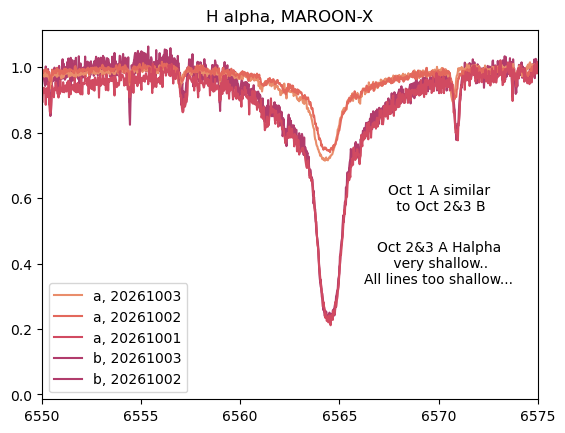

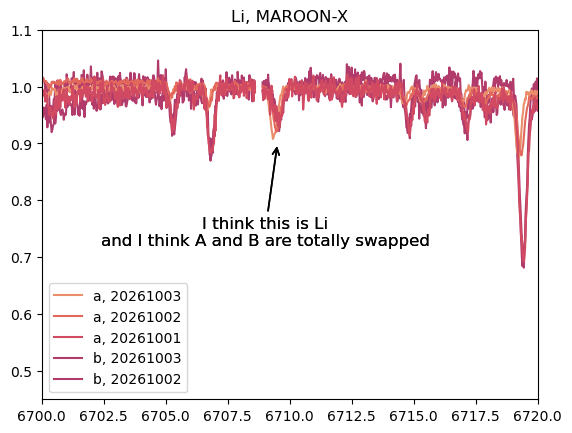

In [8]:
def line_contnorm(wave, flux, w1, w2):
    """
    Continuum normalization using a straight line through
    the flux at two specified wavelengths.
    """

    # Find pixels closest to requested wavelengths
    i1 = np.nanargmin(np.abs(wave - w1))
    i2 = np.nanargmin(np.abs(wave - w2))

    x1, x2 = wave[i1], wave[i2]
    y1, y2 = flux[i1], flux[i2]

    # Straight-line continuum
    continuum = y1 + (y2 - y1) * (wave - x1) / (x2 - x1)

    return flux / continuum


#----Halpha
arm = "BLUE"    # BLUE OR RED 
order =  2  #RED order 24 has Li, BLUE order 2 has Halpha

if arm == "BLUE":
    extver = 1
elif arm == "RED":
    extver = 2

for j, filename in enumerate(WB74_a_MAROONX_spectra):
    date = filename.split('/')[-1].split('_')[0].split('M')[0].strip('N')
    with fits.open(filename) as hdu:
        fluxes = np.asarray(hdu[("BOX_REDUCED_FIBER_3", extver)].data,dtype=float)[order]
        waves = np.asarray(hdu[("WLS_SIMULTANEOUS_FIBER_3", extver)].data,dtype=float)[order]*10
        plt.plot(waves, line_contnorm(waves, fluxes, 6556, 6575), label=f'a, {date}', c=palette[j])

        

for filename in WB74_b_MAROONX_spectra:
    date = filename.split('/')[-1].split('_')[0].split('M')[0].strip('N')
    with fits.open(filename) as hdu:
        fluxes = np.asarray(hdu[("BOX_REDUCED_FIBER_3", extver)].data,dtype=float)[order]
        waves = np.asarray(hdu[("WLS_SIMULTANEOUS_FIBER_3", extver)].data,dtype=float)[order]*10
        plt.plot(waves, line_contnorm(waves, fluxes, 6556, 6575), c=palette[3], label=f'b, {date}', zorder=0)
        

plt.xlim(6550, 6575)

plt.text(6570, .6, 'Oct 1 A similar\n to Oct 2&3 B', va='center',ha='center')
plt.text(6570, .4, 'Oct 2&3 A Halpha\n very shallow..\nAll lines too shallow...', va='center',ha='center')
plt.title('H alpha, MAROON-X')
plt.legend()

plt.show()


#----Lithium
arm = "RED"    # BLUE OR RED 
order =  24   #RED order 24 has Li, BLUE order 2 has Halpha

if arm == "BLUE":
    extver = 1
elif arm == "RED":
    extver = 2

for j, filename in enumerate(WB74_a_MAROONX_spectra):
    date = filename.split('/')[-1].split('_')[0].split('M')[0].strip('N')
    with fits.open(filename) as hdu:
        fluxes = np.asarray(hdu[("BOX_REDUCED_FIBER_3", extver)].data,dtype=float)[order]
        waves = np.asarray(hdu[("WLS_SIMULTANEOUS_FIBER_3", extver)].data,dtype=float)[order]*10
        plt.plot(waves, line_contnorm(waves, fluxes, 6708, 6711), label=f'a, {date}', c=palette[j])

        

for filename in WB74_b_MAROONX_spectra:
    date = filename.split('/')[-1].split('_')[0].split('M')[0].strip('N')
    with fits.open(filename) as hdu:
        fluxes = np.asarray(hdu[("BOX_REDUCED_FIBER_3", extver)].data,dtype=float)[order]
        waves = np.asarray(hdu[("WLS_SIMULTANEOUS_FIBER_3", extver)].data,dtype=float)[order]*10
        plt.plot(waves, line_contnorm(waves, fluxes, 6708, 6711), c=palette[3], label=f'b, {date}', zorder=0)
        plt.annotate('I think this is Li\nand I think A and B are totally swapped',xy=(6709.5, 0.90),xytext=(6709, 0.72),  
            ha='center',fontsize=12,arrowprops=dict(arrowstyle='->',lw=1.2))

plt.xlim(6700, 6720)
plt.ylim(.45, 1.1)
# plt.text(6570, .6, 'Oct 1 A similar\n to Oct 2&3 B', va='center',ha='center')
# plt.text(6570, .4, 'Oct 2&3 A Halpha\n very shallow..\nAll lines too shallow...', va='center',ha='center')
plt.title('Li, MAROON-X')
plt.legend()
plt.show()

Maroon-X pointing sanity check: did we point at what we thought we were pointing at?

NOTE: This still doesn't confirm aquisition accuracy

In [9]:
from astropy.io import fits

files = [
    "/home/catherine-manea/Software/MAROONXDR/Data_oct1/N20261001M5559.fits",  #A
    "/home/catherine-manea/Software/MAROONXDR/Data_oct2/N20261002M5616.fits",  # B
    "/home/catherine-manea/Software/MAROONXDR/Data_oct2/N20261002M5643.fits",  # A
    "/home/catherine-manea/Software/MAROONXDR/Data_oct3/N20261003M5421.fits",  # B
    "/home/catherine-manea/Software/MAROONXDR/Data_oct3/N20261003M5458.fits",  # A
]

for filename in files:

    with fits.open(filename) as hdu:
        hdr = hdu[0].header
        print("\n", filename.split("/")[-1])
        for key in ["OBJECT","DATE-OBS","TELRA","TELDEC","RA", "DEC"]:
            if key in hdr:
                print(f"{key} = {hdr[key]}")


 N20261001M5559.fits
OBJECT = HD 79872A
DATE-OBS = 2026-10-01T15:26:29.000
RA = 139.3298125
DEC = 23.65221666666666

 N20261002M5616.fits
OBJECT = HD 79872B
DATE-OBS = 2026-10-02T15:35:55.000
RA = 139.3306916666667
DEC = 23.65365277777778

 N20261002M5643.fits
OBJECT = HD 79872A
DATE-OBS = 2026-10-02T15:40:28.000
RA = 139.3297916666667
DEC = 23.65222222222222

 N20261003M5421.fits
OBJECT = HD 79872B
DATE-OBS = 2026-10-03T15:03:32.000
RA = 139.330725
DEC = 23.65364444444444

 N20261003M5458.fits
OBJECT = HD 79872A
DATE-OBS = 2026-10-03T15:09:36.000
RA = 139.3298208333333
DEC = 23.65221388888889


## Here is a summary of the RVs I get from both the Tull and MAROON-X spectra after applying barycentric corrections

## HD 79872 Radial Velocities

| Date | Star | Observation midpoint (UTC) | Barycentric RV (km/s) | $\sigma_{\rm RV}$ (km/s) | Notes |
|---|---|---|---:|---:|---|
| 2025-01-07 | **HD 79872 A** | 10:08:00 | +19.607 | 0.260 | WB74a |
| 2025-01-07 | **HD 79872 B** | 10:21:23 | +27.895 | 0.230 | WB74a |
| 2026-10-01 | **HD 79872 A** | 15:26:59 | +20.182 | 0.618 | I actually think this is what we've been calling WB74a |
| 2026-10-02 | **HD 79872 A** | 15:40:58 | +16.616 | 0.597 | I actually think this is what we've been calling WB74b |
| 2026-10-02 | **HD 79872 B** | 15:36:25 | +20.198 | 0.745 | I actually think this is what we've been calling WB74a |
| 2026-10-03 | **HD 79872 A** | 15:10:06 | +11.800 | 0.559 | I actually think this is what we've been calling WB74b |
| 2026-10-03 | **HD 79872 B** | 15:04:02 | +20.174 | 0.740 | I actually think this is what we've been calling WB74a |

**Instruments**
- **2025-01-07:** Tull Coudé / HJST
- **2026-10-01 through 2026-10-03:** MAROON-X / Gemini North

## Final Takeaways

1) The "A" observations from Oct 2 & 3 have issues--absorption lines are too shallow everywhere
2) The "B" observations on Oct 2 & 3 look nearly identical to the "A" observation on Oct 1 -- the pointing of the telescope looked good, but it is possible that the acquisition was inaccurate and they accidencally observed "B" on the first night.
3) "A" shows night-to-night RV variability.
4) "B" is remarkable stable night-to-night.
5) I think WB74A might actually be HD79832B and vice versa. Under this assumption, WB74a is the stable one and WB74b varies.
6) There are also signs of H alpha flux variation. These cannot be confirmed until we fix the reductions.

### Let's try to fix the shallow lines in the Oct 2&3 "A" by stretching the spectrum.  This is purely to diagnose what's going on.

In [24]:
def stretch_spectrum(flux, factor):
    return 1 + factor * (flux - 1)

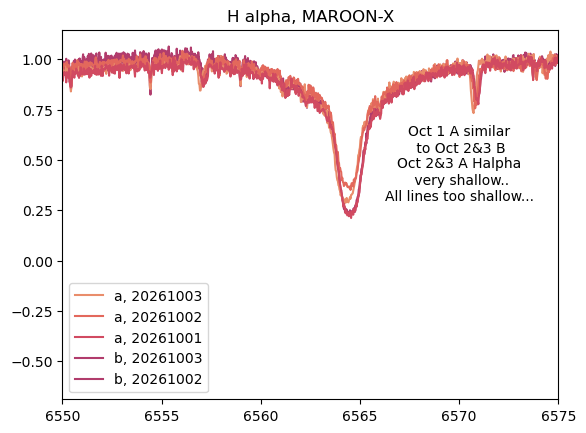

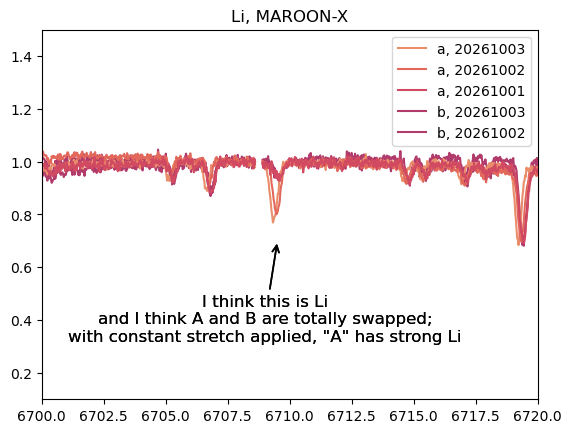

In [26]:
stretch_factor = 2.5


#----Halpha
arm = "BLUE"    # BLUE OR RED 
order =  2  #RED order 24 has Li, BLUE order 2 has Halpha

if arm == "BLUE":
    extver = 1
elif arm == "RED":
    extver = 2

for j, filename in enumerate(WB74_a_MAROONX_spectra):
    date = filename.split('/')[-1].split('_')[0].split('M')[0].strip('N')
    with fits.open(filename) as hdu:
        fluxes = np.asarray(hdu[("BOX_REDUCED_FIBER_3", extver)].data,dtype=float)[order]
        waves = np.asarray(hdu[("WLS_SIMULTANEOUS_FIBER_3", extver)].data,dtype=float)[order]*10

        if '1001' in date:
            sf = 1
        else:
            sf = stretch_factor
            
        plt.plot(waves, stretch_spectrum(line_contnorm(waves, fluxes, 6556, 6575),sf), label=f'a, {date}', c=palette[j])

        

for filename in WB74_b_MAROONX_spectra:
    date = filename.split('/')[-1].split('_')[0].split('M')[0].strip('N')
    with fits.open(filename) as hdu:
        fluxes = np.asarray(hdu[("BOX_REDUCED_FIBER_3", extver)].data,dtype=float)[order]
        waves = np.asarray(hdu[("WLS_SIMULTANEOUS_FIBER_3", extver)].data,dtype=float)[order]*10
        sf = 1
        plt.plot(waves, stretch_spectrum(line_contnorm(waves, fluxes, 6556, 6575), sf), c=palette[3], label=f'b, {date}', zorder=0)
        

plt.xlim(6550, 6575)

plt.text(6570, .6, 'Oct 1 A similar\n to Oct 2&3 B', va='center',ha='center')
plt.text(6570, .4, 'Oct 2&3 A Halpha\n very shallow..\nAll lines too shallow...', va='center',ha='center')
plt.title('H alpha, MAROON-X')
plt.legend()

plt.show()


#----Lithium
arm = "RED"    # BLUE OR RED 
order =  24   #RED order 24 has Li, BLUE order 2 has Halpha

if arm == "BLUE":
    extver = 1
elif arm == "RED":
    extver = 2

for j, filename in enumerate(WB74_a_MAROONX_spectra):
    date = filename.split('/')[-1].split('_')[0].split('M')[0].strip('N')
    with fits.open(filename) as hdu:
        fluxes = np.asarray(hdu[("BOX_REDUCED_FIBER_3", extver)].data,dtype=float)[order]
        waves = np.asarray(hdu[("WLS_SIMULTANEOUS_FIBER_3", extver)].data,dtype=float)[order]*10
        if '1001' in date:
            sf = 1
        else:
            sf = stretch_factor
        plt.plot(waves, stretch_spectrum(line_contnorm(waves, fluxes, 6708, 6711), sf), label=f'a, {date}', c=palette[j])


for filename in WB74_b_MAROONX_spectra:
    date = filename.split('/')[-1].split('_')[0].split('M')[0].strip('N')
    with fits.open(filename) as hdu:
        fluxes = np.asarray(hdu[("BOX_REDUCED_FIBER_3", extver)].data,dtype=float)[order]
        waves = np.asarray(hdu[("WLS_SIMULTANEOUS_FIBER_3", extver)].data,dtype=float)[order]*10
        sf = 1
        plt.plot(waves, stretch_spectrum(line_contnorm(waves, fluxes, 6708, 6711), sf), c=palette[3], label=f'b, {date}', zorder=0)
        plt.annotate('I think this is Li\nand I think A and B are totally swapped;\nwith constant stretch applied, "A" has strong Li',xy=(6709.5, 0.70),xytext=(6709, 0.32),  
            ha='center',fontsize=12,arrowprops=dict(arrowstyle='->',lw=1.2))

plt.xlim(6700, 6720)
plt.ylim(.1, 1.5)
# plt.text(6570, .6, 'Oct 1 A similar\n to Oct 2&3 B', va='center',ha='center')
# plt.text(6570, .4, 'Oct 2&3 A Halpha\n very shallow..\nAll lines too shallow...', va='center',ha='center')
plt.title('Li, MAROON-X')
plt.legend()
plt.show()